Running in Jupyter notebook mode
Loaded data: K = 2 to 50
Entries: 49

✓ Plot saved to output/db_index_plot.png
✓ Simple plot saved to output/db_index_plot_simple.png


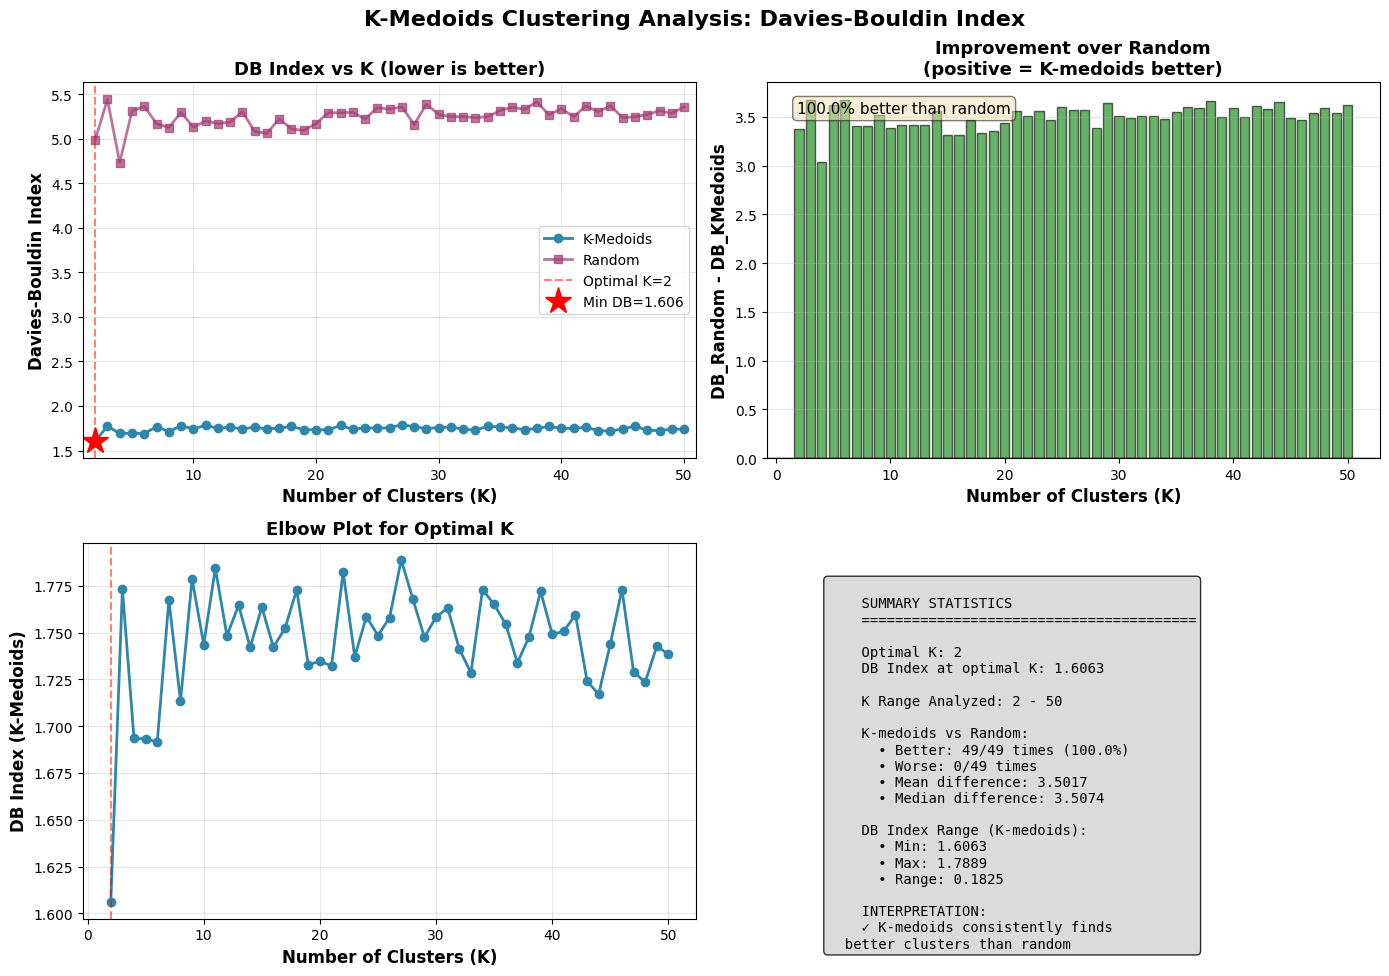

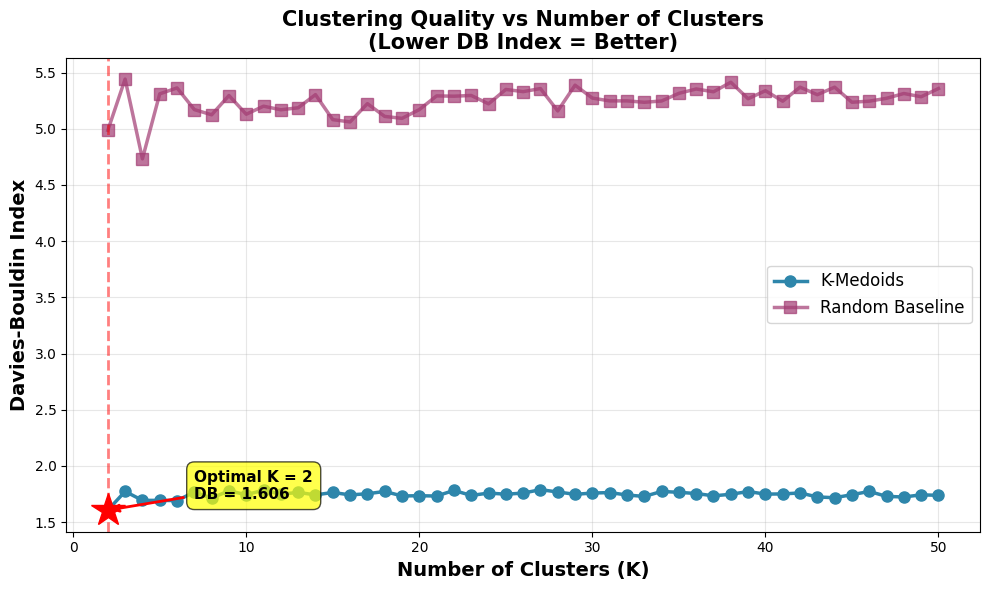


RECOMMENDATIONS
✓ K-medoids works well (beats random 100.0% of time)

Optimal configuration:
  • K = 2 clusters
  • Davies-Bouldin Index = 1.6063

Extract representative snapshots:
  • Check output/optimal_centroids.txt
  • Visualize these snapshots in VMD/PyMOL


In [8]:
#!/usr/bin/env python3
"""
Plot Davies-Bouldin Index analysis results from K-medoids clustering
Works in both Jupyter notebooks and command line
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import sys
import os

def plot_db_analysis(csv_file='output/db_index_vs_K.csv', 
                     output_file='output/db_index_plot.png'):
    """
    Create comprehensive visualization of Davies-Bouldin index analysis
    """
    
    # Check if file exists
    if not os.path.exists(csv_file):
        print(f"Error: {csv_file} not found!")
        print("Run the C++ program first to generate the data.")
        return None, None, None
    
    # Load data
    df = pd.read_csv(csv_file)
    print(f"Loaded data: K = {df['K'].min()} to {df['K'].max()}")
    print(f"Entries: {len(df)}")
    
    # Create figure with subplots
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    fig.suptitle('K-Medoids Clustering Analysis: Davies-Bouldin Index', 
                 fontsize=16, fontweight='bold')
    
    # ============================================
    # Plot 1: DB Index comparison
    # ============================================
    ax1 = axes[0, 0]
    ax1.plot(df['K'], df['DB_KMedoids'], 'o-', linewidth=2, 
             markersize=6, label='K-Medoids', color='#2E86AB')
    ax1.plot(df['K'], df['DB_Random'], 's-', linewidth=2, 
             markersize=6, label='Random', color='#A23B72', alpha=0.7)
    
    # Mark optimal K
    optimal_idx = df['DB_KMedoids'].idxmin()
    optimal_K = df.loc[optimal_idx, 'K']
    optimal_DB = df.loc[optimal_idx, 'DB_KMedoids']
    
    ax1.axvline(optimal_K, color='red', linestyle='--', alpha=0.5, 
                label=f'Optimal K={optimal_K}')
    ax1.plot(optimal_K, optimal_DB, 'r*', markersize=20, 
             label=f'Min DB={optimal_DB:.3f}')
    
    ax1.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Davies-Bouldin Index', fontsize=12, fontweight='bold')
    ax1.set_title('DB Index vs K (lower is better)', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(df['K'].min() - 1, df['K'].max() + 1)
    
    # ============================================
    # Plot 2: Difference (Random - K-medoids)
    # ============================================
    ax2 = axes[0, 1]
    colors = ['green' if x > 0 else 'red' for x in df['Difference']]
    ax2.bar(df['K'], df['Difference'], color=colors, alpha=0.6, edgecolor='black')
    ax2.axhline(0, color='black', linestyle='-', linewidth=1)
    
    ax2.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('DB_Random - DB_KMedoids', fontsize=12, fontweight='bold')
    ax2.set_title('Improvement over Random\n(positive = K-medoids better)', 
                  fontsize=13, fontweight='bold')
    ax2.grid(True, alpha=0.3, axis='y')
    
    # Add statistics
    percent_better = (df['Difference'] > 0).sum() / len(df) * 100
    ax2.text(0.05, 0.95, f'{percent_better:.1f}% better than random', 
             transform=ax2.transAxes, fontsize=11, verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    
    # ============================================
    # Plot 3: Elbow plot (relative change in DB)
    # ============================================
    ax3 = axes[1, 0]
    db_values = df['DB_KMedoids'].values
    
    # Compute rate of change
    rate_of_change = np.zeros(len(db_values))
    rate_of_change[1:] = np.diff(db_values)
    
    ax3.plot(df['K'], db_values, 'o-', linewidth=2, markersize=6, color='#2E86AB')
    ax3.set_xlabel('Number of Clusters (K)', fontsize=12, fontweight='bold')
    ax3.set_ylabel('DB Index (K-Medoids)', fontsize=12, fontweight='bold')
    ax3.set_title('Elbow Plot for Optimal K', fontsize=13, fontweight='bold')
    ax3.grid(True, alpha=0.3)
    
    # Add vertical line at optimal K
    ax3.axvline(optimal_K, color='red', linestyle='--', alpha=0.5)
    
    # ============================================
    # Plot 4: Statistics table
    # ============================================
    ax4 = axes[1, 1]
    ax4.axis('off')
    
    # Calculate statistics
    mean_diff = df['Difference'].mean()
    median_diff = df['Difference'].median()
    better_count = (df['Difference'] > 0).sum()
    worse_count = (df['Difference'] <= 0).sum()
    
    stats_text = f"""
    SUMMARY STATISTICS
    {'='*40}
    
    Optimal K: {optimal_K}
    DB Index at optimal K: {optimal_DB:.4f}
    
    K Range Analyzed: {df['K'].min()} - {df['K'].max()}
    
    K-medoids vs Random:
      • Better: {better_count}/{len(df)} times ({percent_better:.1f}%)
      • Worse: {worse_count}/{len(df)} times
      • Mean difference: {mean_diff:.4f}
      • Median difference: {median_diff:.4f}
    
    DB Index Range (K-medoids):
      • Min: {df['DB_KMedoids'].min():.4f}
      • Max: {df['DB_KMedoids'].max():.4f}
      • Range: {df['DB_KMedoids'].max() - df['DB_KMedoids'].min():.4f}
    
    INTERPRETATION:
    """
    
    if percent_better > 70:
        interpretation = "✓ K-medoids consistently finds\n  better clusters than random"
    elif percent_better > 50:
        interpretation = "≈ K-medoids moderately better\n  than random"
    else:
        interpretation = "⚠ K-medoids struggles to beat\n  random clustering\n  → Data may not have clear clusters"
    
    stats_text += interpretation
    
    ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes, 
             fontsize=10, verticalalignment='top', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
    
    # ============================================
    # Save and display
    # ============================================
    plt.tight_layout()
    
    # Create output directory if it doesn't exist
    os.makedirs(os.path.dirname(output_file) if os.path.dirname(output_file) else '.', exist_ok=True)
    
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"\n✓ Plot saved to {output_file}")
    
    # Also create a simple focused plot
    fig2, ax = plt.subplots(figsize=(10, 6))
    ax.plot(df['K'], df['DB_KMedoids'], 'o-', linewidth=2.5, 
            markersize=8, label='K-Medoids', color='#2E86AB')
    ax.plot(df['K'], df['DB_Random'], 's-', linewidth=2.5, 
            markersize=8, label='Random Baseline', color='#A23B72', alpha=0.7)
    
    ax.axvline(optimal_K, color='red', linestyle='--', alpha=0.5, linewidth=2)
    ax.plot(optimal_K, optimal_DB, 'r*', markersize=25)
    
    ax.set_xlabel('Number of Clusters (K)', fontsize=14, fontweight='bold')
    ax.set_ylabel('Davies-Bouldin Index', fontsize=14, fontweight='bold')
    ax.set_title('Clustering Quality vs Number of Clusters\n(Lower DB Index = Better)', 
                 fontsize=15, fontweight='bold')
    ax.legend(fontsize=12)
    ax.grid(True, alpha=0.3)
    
    # Add annotation for optimal K
    ax.annotate(f'Optimal K = {optimal_K}\nDB = {optimal_DB:.3f}',
                xy=(optimal_K, optimal_DB), xytext=(optimal_K + 5, optimal_DB + 0.1),
                fontsize=11, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7),
                arrowprops=dict(arrowstyle='->', lw=2, color='red'))
    
    simple_file = output_file.replace('.png', '_simple.png')
    plt.tight_layout()
    plt.savefig(simple_file, dpi=300, bbox_inches='tight')
    print(f"✓ Simple plot saved to {simple_file}")
    
    plt.show()
    
    # Print recommendations
    print("\n" + "="*60)
    print("RECOMMENDATIONS")
    print("="*60)
    
    if percent_better < 50:
        print("⚠️  K-medoids rarely beats random clustering")
        print("\nPossible reasons:")
        print("  1. Data doesn't have well-separated clusters")
        print("  2. Too many atoms (include only backbone)")
        print("  3. RMSD may not be the best metric")
        print("\nNext steps:")
        print("  • Try PCA to reduce dimensionality first")
        print("  • Use dihedral angles instead of Cartesian RMSD")
        print("  • Try density-based clustering (DBSCAN)")
        print("  • Consider Markov State Models (MSM)")
    else:
        print(f"✓ K-medoids works well (beats random {percent_better:.1f}% of time)")
        print(f"\nOptimal configuration:")
        print(f"  • K = {optimal_K} clusters")
        print(f"  • Davies-Bouldin Index = {optimal_DB:.4f}")
        print(f"\nExtract representative snapshots:")
        print(f"  • Check output/optimal_centroids.txt")
        print(f"  • Visualize these snapshots in VMD/PyMOL")
    
    print("="*60)
    
    return df, optimal_K, optimal_DB


# ============================================
# Main execution
# ============================================
if __name__ == "__main__":
    # Check if running in Jupyter
    try:
        get_ipython()
        in_jupyter = True
    except NameError:
        in_jupyter = False
    
    if in_jupyter:
        # Running in Jupyter - use default paths
        print("Running in Jupyter notebook mode")
        df, optimal_K, optimal_DB = plot_db_analysis()
    else:
        # Running from command line - use argparse
        import argparse
        
        parser = argparse.ArgumentParser(description='Plot Davies-Bouldin index analysis')
        parser.add_argument('--input', default='output/db_index_vs_K.csv',
                            help='Input CSV file (default: output/db_index_vs_K.csv)')
        parser.add_argument('--output', default='output/db_index_plot.png',
                            help='Output plot file (default: output/db_index_plot.png)')
        
        args = parser.parse_args()
        
        df, optimal_K, optimal_DB = plot_db_analysis(args.input, args.output)


# ============================================
# Jupyter-friendly direct call
# ============================================
# If you're in Jupyter, just run:
#   plot_db_analysis()
# 
# Or with custom paths:
#   plot_db_analysis('my_data.csv', 'my_plot.png')

Loaded 999 RMSD values  (frames 1 – 999)
✓ RMSD plot saved to output/rmsd_row0_plot.png
RMSD SUMMARY (frame 0 vs frames 1–999)
  Min    : 25.6912 Å  (frame 1)
  Max    : 52.8071 Å  (frame 739)
  Mean   : 52.0753 Å
  Median : 52.4668 Å
  Std    : 2.0458 Å


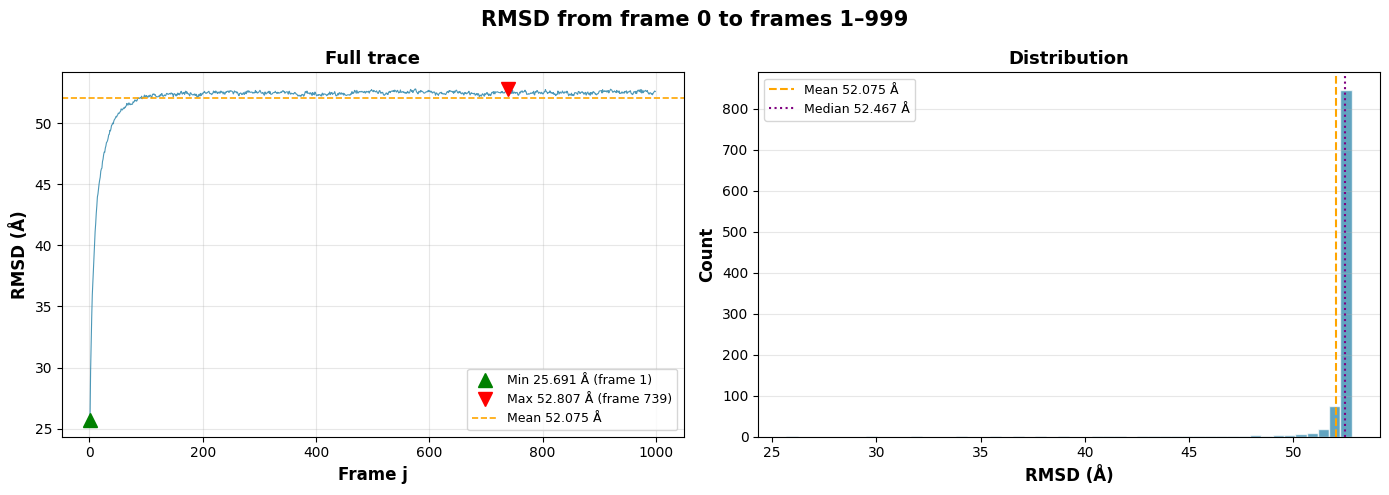

In [9]:
#!/usr/bin/env python3
"""
Plot RMSD between frame 0 and the first 1000 frames.
Reads output/rmsd_row0.txt produced by the C++ program.
Each line: <frame_index> <rmsd_value>
"""

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os


def plot_rmsd_row0(rmsd_file='output/rmsd_row0_full.txt',
                   output_file='output/rmsd_row0_plot.png'):
    """
    Plot RMSD(0, j) for j = 1..999 from the packed upper-triangle dump.
    """
    if not os.path.exists(rmsd_file):
        print(f"Error: {rmsd_file} not found!")
        print("Add the export snippet to the C++ program to generate it.")
        return

    df = pd.read_csv(rmsd_file, sep=r'\s+', header=None, names=['frame', 'rmsd'])
    print(f"Loaded {len(df)} RMSD values  (frames {df['frame'].min()} – {df['frame'].max()})")

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('RMSD from frame 0 to frames 1–999', fontsize=15, fontweight='bold')

    # ── Left: full trace ──────────────────────────────────────────────────
    ax1 = axes[0]
    ax1.plot(df['frame'], df['rmsd'], linewidth=0.8, color='#2E86AB', alpha=0.85)
    ax1.set_xlabel('Frame j', fontsize=12, fontweight='bold')
    ax1.set_ylabel('RMSD (Å)', fontsize=12, fontweight='bold')
    ax1.set_title('Full trace', fontsize=13, fontweight='bold')
    ax1.grid(True, alpha=0.3)

    # Highlight min and max
    idx_min = df['rmsd'].idxmin()
    idx_max = df['rmsd'].idxmax()
    ax1.plot(df.loc[idx_min, 'frame'], df.loc[idx_min, 'rmsd'],
             'g^', markersize=10, label=f'Min {df.loc[idx_min, "rmsd"]:.3f} Å (frame {df.loc[idx_min, "frame"]})')
    ax1.plot(df.loc[idx_max, 'frame'], df.loc[idx_max, 'rmsd'],
             'rv', markersize=10, label=f'Max {df.loc[idx_max, "rmsd"]:.3f} Å (frame {df.loc[idx_max, "frame"]})')
    ax1.axhline(df['rmsd'].mean(), color='orange', linestyle='--', linewidth=1.2,
                label=f'Mean {df["rmsd"].mean():.3f} Å')
    ax1.legend(fontsize=9)

    # ── Right: histogram ─────────────────────────────────────────────────
    ax2 = axes[1]
    n, bins, patches = ax2.hist(df['rmsd'], bins=50, color='#2E86AB', alpha=0.75, edgecolor='white')
    ax2.axvline(df['rmsd'].mean(),  color='orange', linestyle='--', linewidth=1.5,
                label=f'Mean {df["rmsd"].mean():.3f} Å')
    ax2.axvline(df['rmsd'].median(), color='purple', linestyle=':',  linewidth=1.5,
                label=f'Median {df["rmsd"].median():.3f} Å')
    ax2.set_xlabel('RMSD (Å)', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Count', fontsize=12, fontweight='bold')
    ax2.set_title('Distribution', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3, axis='y')

    plt.tight_layout()
    os.makedirs(os.path.dirname(output_file) if os.path.dirname(output_file) else '.', exist_ok=True)
    plt.savefig(output_file, dpi=300, bbox_inches='tight')
    print(f"✓ RMSD plot saved to {output_file}")

    # Print summary stats
    print("" + "="*50)
    print("RMSD SUMMARY (frame 0 vs frames 1–999)")
    print("="*50)
    print(f"  Min    : {df['rmsd'].min():.4f} Å  (frame {df.loc[idx_min, 'frame']})")
    print(f"  Max    : {df['rmsd'].max():.4f} Å  (frame {df.loc[idx_max, 'frame']})")
    print(f"  Mean   : {df['rmsd'].mean():.4f} Å")
    print(f"  Median : {df['rmsd'].median():.4f} Å")
    print(f"  Std    : {df['rmsd'].std():.4f} Å")
    print("="*50)

    plt.show()


# ── Run ───────────────────────────────────────────────────────────────────
plot_rmsd_row0()


Comparing 999 values
  Max absolute error : 3816.629333 Å
  Mean absolute error: 2573.837517 Å
  RMSE               : 50.147052 Å
  Max relative error : 304729.4921 %
  Pearson r          : 0.55693719
✓ Comparison plot saved to output/rmsd_row0_comparison.png


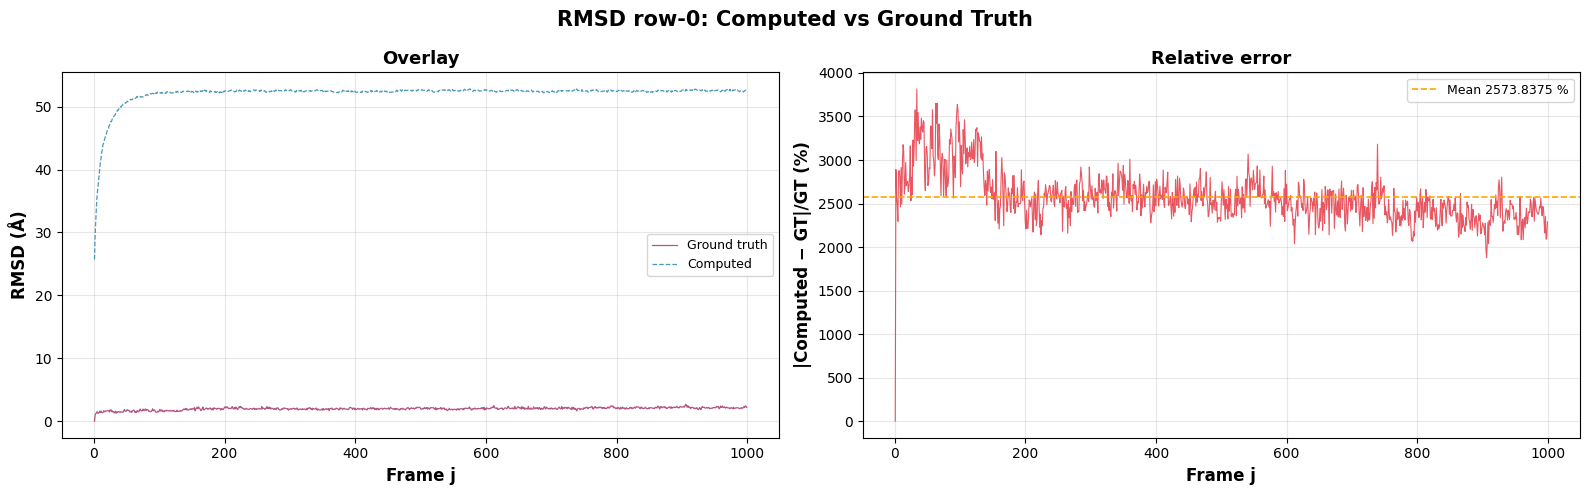

In [10]:
#!/usr/bin/env python3
"""
Compare computed RMSD (row 0) against ground-truth values.
  - output/rmsd_row0.txt    : two columns, space-separated  (<frame> <rmsd>)
  - output/rmsd_row0_GT.txt : comma-separated values only   (no frame index)
"""

import numpy as np
import matplotlib.pyplot as plt
import os

def compare_rmsd(computed_file='output/rmsd_row0_full.txt',
                 gt_file='output/rmsd_row0_GT.txt'):

    # ── Load computed ────────────────────────────────────────────────────
    if not os.path.exists(computed_file):
        print(f"Error: {computed_file} not found!")
        return
    computed = np.loadtxt(computed_file, usecols=1)   # second column

    # ── Load ground truth ────────────────────────────────────────────────
    if not os.path.exists(gt_file):
        print(f"Error: {gt_file} not found!")
        return
    with open(gt_file) as f:
        raw = f.read()
    gt = np.array([float(x) for x in raw.split(',') if x.strip()])

    # ── Align lengths ────────────────────────────────────────────────────
    n = min(len(computed), len(gt))
    computed, gt = computed[:n], gt[:n]
    frames = np.arange(1, n + 1)

    diff   = computed - gt
    abs_diff = 100 * np.abs(diff)/gt
    abs_diff[0] = 0

    print(f"Comparing {n} values")
    print(f"  Max absolute error : {abs_diff.max():.6f} Å")
    print(f"  Mean absolute error: {abs_diff.mean():.6f} Å")
    print(f"  RMSE               : {np.sqrt((diff**2).mean()):.6f} Å")
    print(f"  Max relative error : {(abs_diff / (gt + 1e-12)).max() * 100:.4f} %")
    print(f"  Pearson r          : {np.corrcoef(computed, gt)[0,1]:.8f}")

    # ── Plot ─────────────────────────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle('RMSD row-0: Computed vs Ground Truth', fontsize=15, fontweight='bold')

    # 1) Overlay trace
    ax1 = axes[0]
    ax1.plot(frames, gt,       linewidth=0.9, color='#A23B72', alpha=0.85, label='Ground truth')
    ax1.plot(frames, computed, linewidth=0.9, color='#2E86AB', alpha=0.85, label='Computed', linestyle='--')
    ax1.set_xlabel('Frame j', fontsize=12, fontweight='bold')
    ax1.set_ylabel('RMSD (Å)', fontsize=12, fontweight='bold')
    ax1.set_title('Overlay', fontsize=13, fontweight='bold')
    ax1.legend(fontsize=9)
    ax1.grid(True, alpha=0.3)

    # 2) Absolute error trace
    ax2 = axes[1]
    ax2.plot(frames, abs_diff, linewidth=0.8, color='#E63946', alpha=0.85)
    ax2.axhline(abs_diff.mean(), color='orange', linestyle='--', linewidth=1.2,
                label=f'Mean {abs_diff.mean():.4f} %')
    ax2.set_xlabel('Frame j', fontsize=12, fontweight='bold')
    ax2.set_ylabel('|Computed − GT|/GT (%)', fontsize=12, fontweight='bold')
    ax2.set_title('Relative error', fontsize=13, fontweight='bold')
    ax2.legend(fontsize=9)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    out_file = 'output/rmsd_row0_comparison.png'
    os.makedirs('output', exist_ok=True)
    plt.savefig(out_file, dpi=300, bbox_inches='tight')
    print(f"✓ Comparison plot saved to {out_file}")
    plt.show()


compare_rmsd()
